In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config

target_volatility = 'Sq_Log_Return'

# macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
# macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block
# macro_shocks = ['NFP_Suprise', 'Retail_Sales_Suprise']

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-21 22:57:41 - src.data_loader - INFO - Configuration matches cache. Loading data from disk...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(stat_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=5)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=9, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-21 22:57:41 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-21 22:57:41 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK

--- Granger Causality: Macro -> XLK ---
[Unemployment_Surprise]
  Lag 1: p-value = 0.1338 
  Lag 2: p-value = 0.4742 
  Lag 3: p-value = 0.6605 
  Lag 4: p-value = 0.5588 
  Lag 5: p-value = 0.9252 
[Housing_Starts_Surprise]
  Lag 1: p-value = 0.0084 ***
  Lag 2: p-value = 0.1010 
  Lag 3: p-value = 0.2792 
  Lag 4: p-value = 0.5451 
  Lag 5: p-value = 0.7538 

Fitting VAR Model for XLK...


2026-06-21 22:57:45 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-21 22:57:45 - src.features - INFO - Calculating Autoregressive Macro Surprises...



LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -6.105      -6.101    0.002233      -6.104
1      -11.18      -11.17   1.397e-05      -11.17
2      -11.23      -11.21   1.323e-05      -11.23
3      -11.24      -11.21   1.314e-05      -11.23
4      -11.25      -11.21   1.294e-05      -11.24
5      -11.27      -11.22   1.280e-05      -11.25
6      -11.28     -11.22*   1.262e-05      -11.26
7      -11.28      -11.21   1.262e-05      -11.26
8      -11.29      -11.21   1.247e-05     -11.26*
9     -11.30*      -11.21  1.243e-05*      -11.26
-------------------------------------------------

PROCESSING SECTOR: XLE

--- Granger Causality: Macro -> XLE ---
[Unemployment_Surprise]
  Lag 1: p-value = 0.0033 ***
  Lag 2: p-value = 0.0907 *
  Lag 3: p-value = 0.2890 
  Lag 4: p-value = 0.1681 
  Lag 5: p-value = 0.1502 
[Housing_Starts_Surprise]
  Lag 1: p-value = 0.0

2026-06-21 22:57:49 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-21 22:57:49 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLF

--- Granger Causality: Macro -> XLF ---
[Unemployment_Surprise]
  Lag 1: p-value = 0.0687 *
  Lag 2: p-value = 0.2403 
  Lag 3: p-value = 0.6530 
  Lag 4: p-value = 0.5815 
  Lag 5: p-value = 0.6280 
[Housing_Starts_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0003 ***
  Lag 5: p-value = 0.0034 ***

Fitting VAR Model for XLF...


2026-06-21 22:57:52 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-21 22:57:52 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLV

--- Granger Causality: Macro -> XLV ---
[Unemployment_Surprise]
  Lag 1: p-value = 0.2564 
  Lag 2: p-value = 0.3490 
  Lag 3: p-value = 0.1599 
  Lag 4: p-value = 0.1289 
  Lag 5: p-value = 0.3265 
[Housing_Starts_Surprise]
  Lag 1: p-value = 0.0493 **
  Lag 2: p-value = 0.4397 
  Lag 3: p-value = 0.7300 
  Lag 4: p-value = 0.8572 
  Lag 5: p-value = 0.9475 

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF  \
                              Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                       0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L1.Unemployment_Surprise   -0.0000  0.6600      -0.0001  0.4536       0.0001   
L1.Housing_Starts_Surprise  0.0000  0.9782      -0.0000  0.3577      -0.0000   
L1.Sq_Log_Return            0.1390  0.0000  *** -0.0067  0.5925       0.1364   
L2.Unemployment_Surprise   -0.0000  0.7964      -0.0000  0.9696      -0.0001   
L2.Housing_Starts_Surprise -0.0000  0.8313       0.0000  0.3143       0.0000   
L2.Sq_Log_Return            0.1407  0.0000  ***  0.1492  0.0000  ***  0.0932   
L3.Unemployment_Surprise    0.0001  0.3600      -0.0001  0.2230      -0.0001   
L3.Housing_Starts_Surprise -0.0000  0.7244      -0.0000  0.8859      -0.0000   
L3.Sq_Log_Return            0.0228  0.0720    *  0.0973  0.0000  ***  0.0459   
L4.Unemployment_Surprise   -0.0000  0.4636       0.0002  0.0095  ***  0.0001   
L4.Housing_Starts_Surprise  0.0000  0.5809      -0.0000  0.7943      -0.0000   
L4.Sq_Log_Return            0.0732  0.0000  ***  0.1710  0.0000  ***  0.0979   
L5.Unemployment_Surprise    0.0000  0.7458      -0.0000  0.9589      -0.0000   
L5.Housing_Starts_Surprise  0.0000  0.6508      -0.0000  0.7206       0.0000   
L5.Sq_Log_Return            0.0792  0.0000  ***  0.1671  0.0000  ***  0.0579   
L6.Unemployment_Surprise   -0.0000  0.4619       0.0001  0.3341      -0.0000   
L6.Housing_Starts_Surprise -0.0000  0.3851       0.0000  0.6434      -0.0000   
L6.Sq_Log_Return            0.1000  0.0000  ***  0.0365  0.0035  ***  0.2025   
L7.Unemployment_Surprise    0.0001  0.3993      -0.0002  0.0964    * -0.0000   
L7.Housing_Starts_Surprise  0.0000  0.7769      -0.0000  0.5360      -0.0000   
L7.Sq_Log_Return            0.0057  0.6553       0.1664  0.0000  ***  0.0621   
L8.Unemployment_Surprise    0.0001  0.4013      -0.0001  0.4909       0.0001   
L8.Housing_Starts_Surprise  0.0000  0.9547       0.0000  0.5259       0.0000   
L8.Sq_Log_Return            0.1037  0.0000  ***  0.0095  0.4474      -0.0000   
L9.Unemployment_Surprise   -0.0001  0.1722       0.0001  0.3505      -0.0000   
L9.Housing_Starts_Surprise -0.0000  0.8019      -0.0000  0.7840      -0.0000   
L9.Sq_Log_Return            0.0423  0.0007  *** -0.0451  0.0003  ***  0.0783   

                                            XLV               
                             P-Val  Sig    Coef   P-Val  Sig  
const                       0.0000  ***  0.0000  0.0000  ***  
L1.Unemployment_Surprise    0.4584      -0.0000  0.0359   **  
L1.Housing_Starts_Surprise  0.4574       0.0000  0.9290       
L1.Sq_Log_Return            0.0000  ***  0.1346  0.0000  ***  
L2.Unemployment_Surprise    0.4712       0.0000  0.5603       
L2.Housing_Starts_Surprise  0.7167      -0.0000  0.7702       
L2.Sq_Log_Return            0.0000  ***  0.3585  0.0000  ***  
L3.Unemployment_Surprise    0.5440       0.0000  0.0947    *  
L3.Housing_Starts_Surprise  0.9251      -0.0000  0.9602       
L3.Sq_Log_Return            0.0003  ***  0.0627  0.0000  ***  
L4.Unemployment_Surprise    0.3916      -0.0000  0.3273       
L4.Housing_Starts_Surprise  0.8281       0.0000  0.7965       
L4.Sq_Log_Return            0.0000  *** -0.0425  0.0014  ***  
L5.Unemployment_Surprise    0.8834       0.0000  0.7757       
L5.Housing_Starts_Surprise  0.9331       0.0000  0.4363       
L5.Sq_Log_Return            0.0000  ***  0.0464  0.0005  ***  
L6.Unemployment_Surprise    0.9028      -0.0000  0.8924       
L6.Housing_Starts_Surprise  0.9024      -0.0000  0.4163       
L6.Sq_Log_Return            0.0000  ***  0.0201  0.1316       
L7.Unemployment_Surprise    0.8051      -0.0000  0.7606       
L7.Housing_Starts_Surprise  0.9809       0.0000  0.9662       
L7.Sq_Log_Return            0.0000  ***  0.0278  0.0364   **  
L8.Unemployment_Surprise    0.5203       0.0000  0.2484       
L8.Housing_Starts_Surprise  0.3469      -0.0000  0.7387

In [4]:
to_show = combined_stats[combined_stats.xs("Sig", axis=1, level=1).isin(["*","**","***"]).any(axis=1)]
display(to_show[~to_show.index.astype(str).str.contains("Return")])

XLK                  XLE                  XLF  \
                            Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                     0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L1.Unemployment_Surprise -0.0000  0.6600      -0.0001  0.4536       0.0001   
L3.Unemployment_Surprise  0.0001  0.3600      -0.0001  0.2230      -0.0001   
L4.Unemployment_Surprise -0.0000  0.4636       0.0002  0.0095  ***  0.0001   
L7.Unemployment_Surprise  0.0001  0.3993      -0.0002  0.0964    * -0.0000   

                                       XLV               
                           P-Val  Sig Coef   P-Val  Sig  
const                     0.0000  ***  0.0  0.0000  ***  
L1.Unemployment_Surprise  0.4584      -0.0  0.0359   **  
L3.Unemployment_Surprise  0.5440       0.0  0.0947    *  
L4.Unemployment_Surprise  0.3916      -0.0  0.3273       
L7.Unemployment_Surprise  0.8051      -0.0  0.7606


VISUAL DIAGNOSTICS: XLK


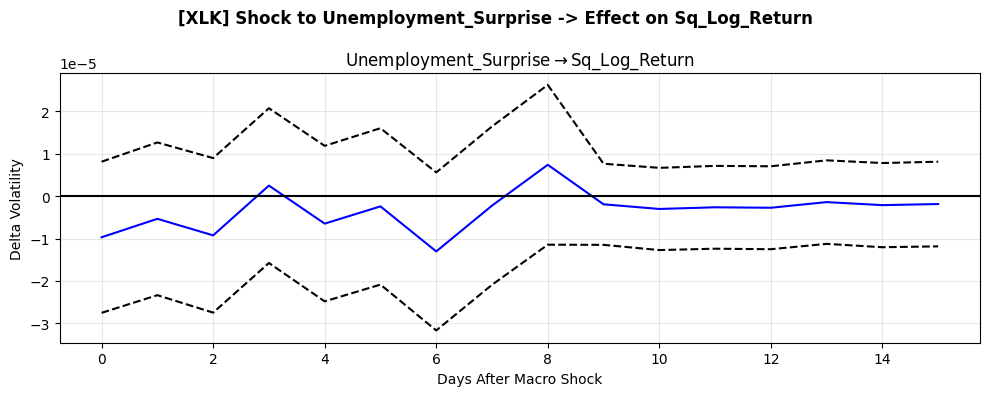

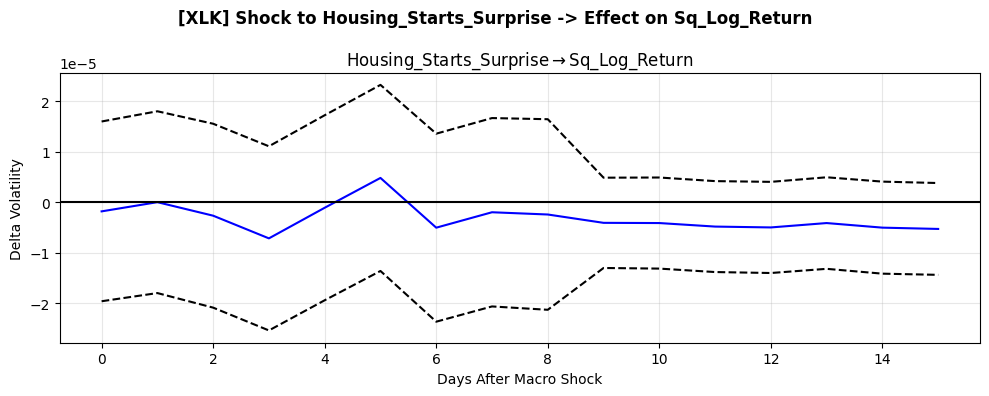

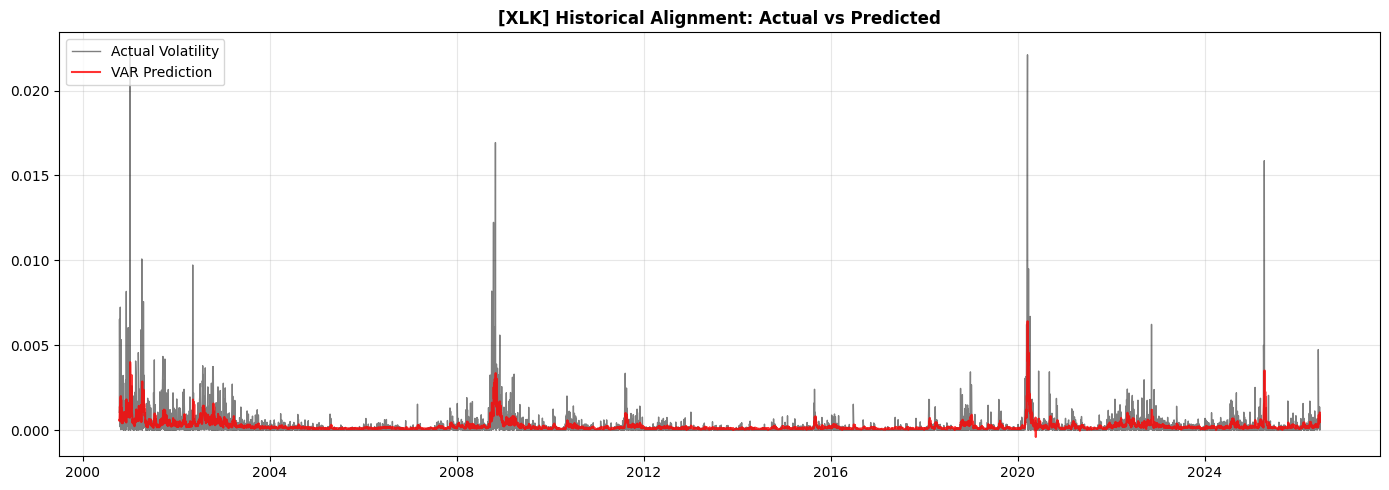


VISUAL DIAGNOSTICS: XLE


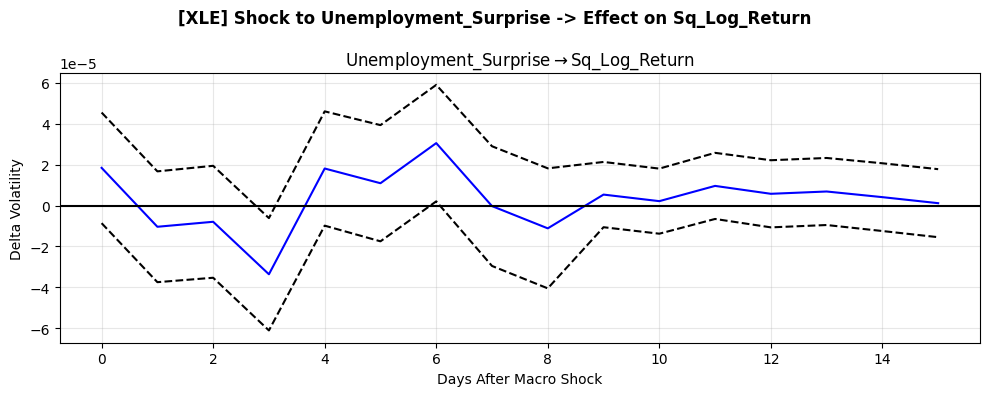

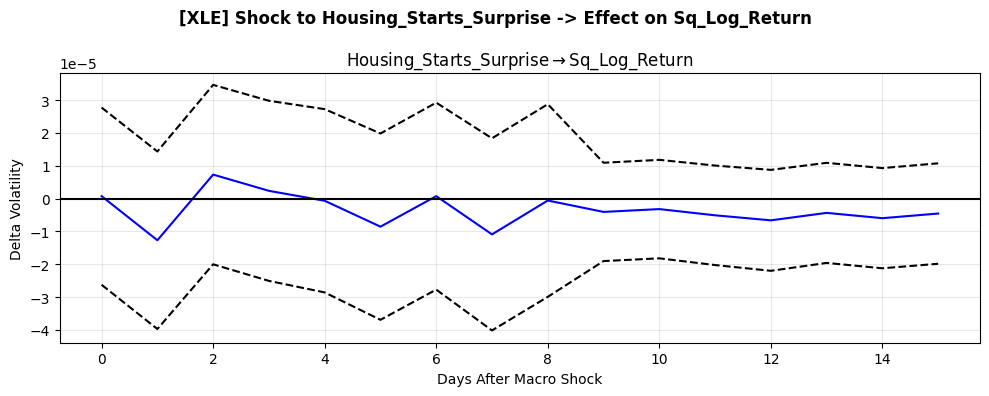

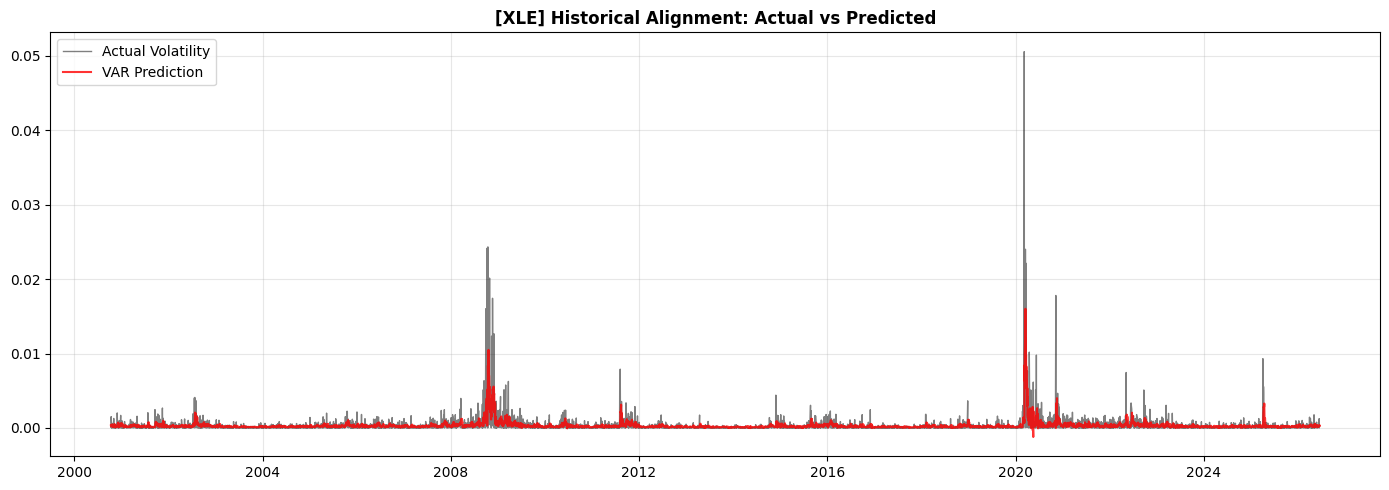


VISUAL DIAGNOSTICS: XLF


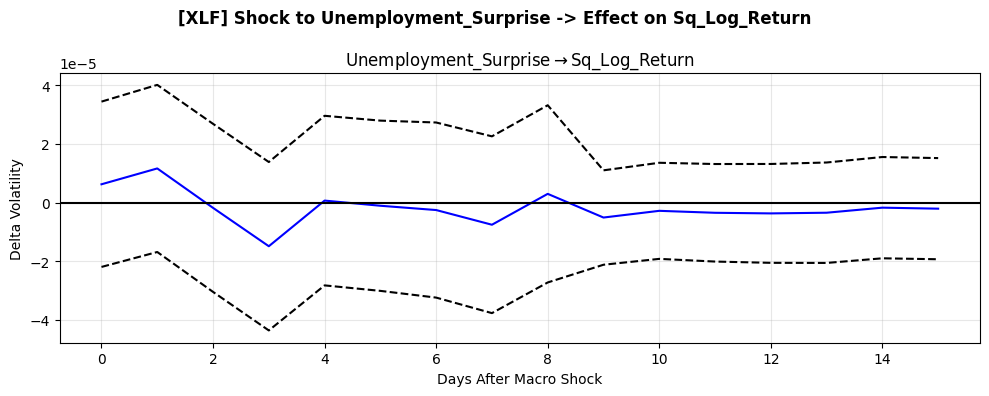

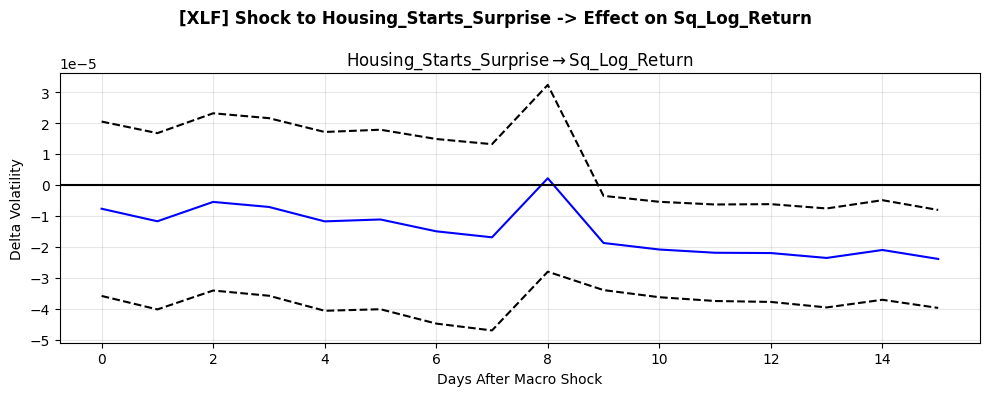

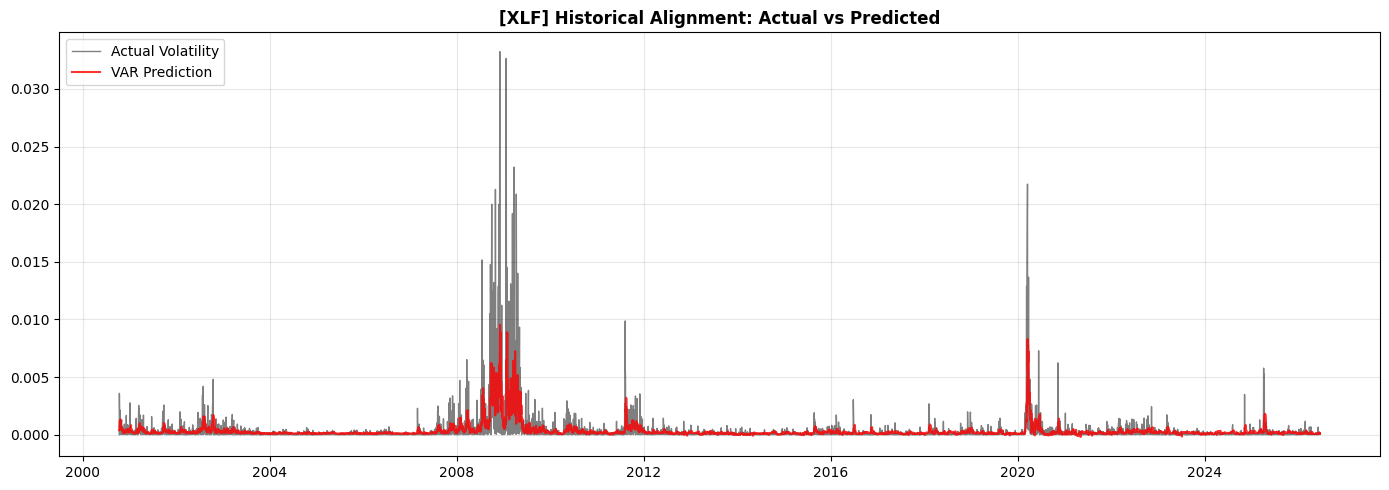


VISUAL DIAGNOSTICS: XLV


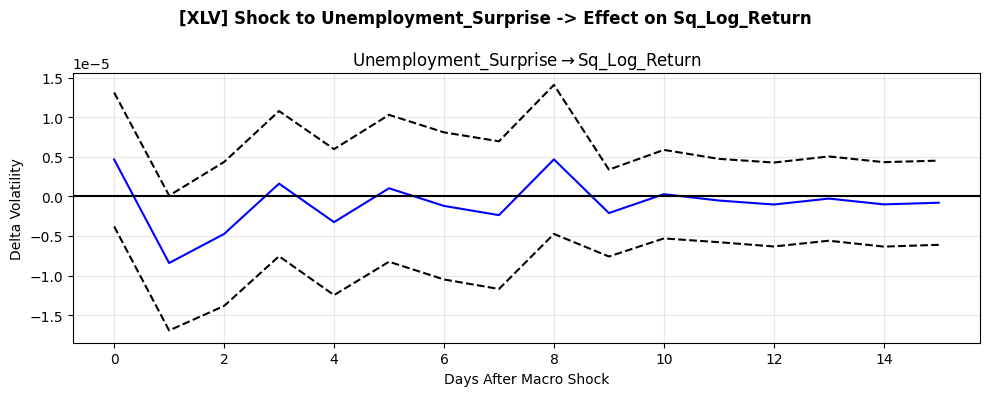

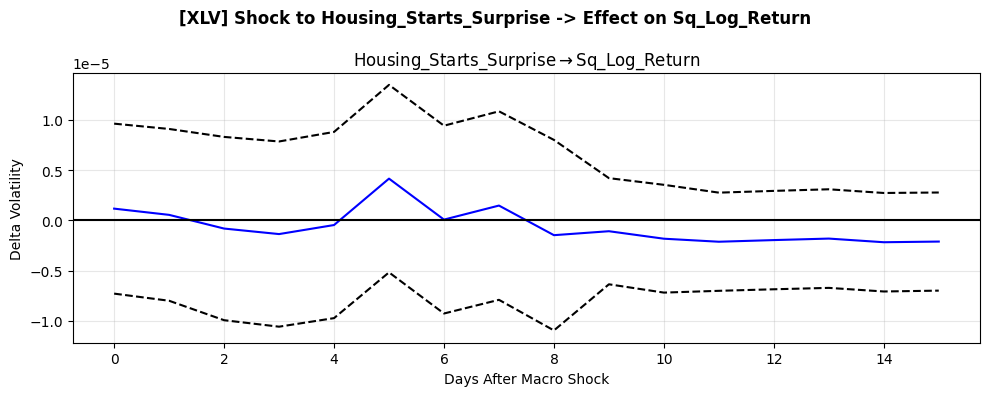

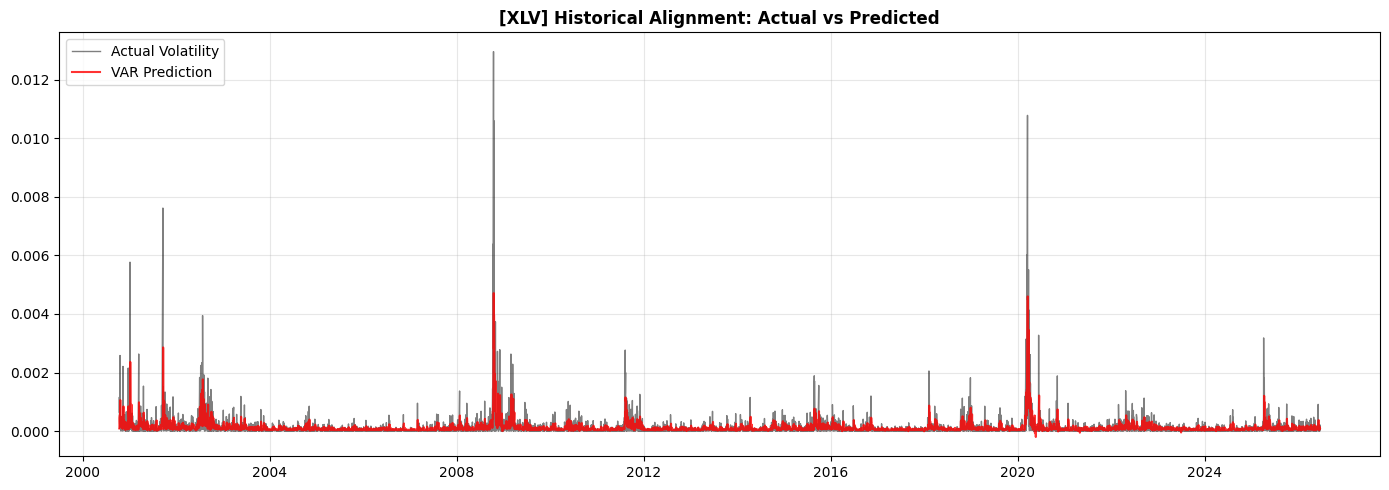

In [5]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
